<div style='text-align: center;'>
<img src="images/math60082-banner.png" alt="image" width="80%" height="auto">
</div>

# Lab Workbook - Week 8


# Tasks


1. Use point estimates of the value function $V$ to derive approximations of $\frac{\partial V}{\partial S}$ and  $\frac{\partial^2 V}{\partial S^2}$.


## How does this help us?


2. Trying sketching out the grid.


3. Consider a small example with $imax=jmax=4$, setup storage arrays for the grid and plot out the value of the option at expiry and the boundary conditions.


In [4]:
# To get started import some libraries
import numpy
import matplotlib.pyplot as plt

In [5]:
# setup the parameters
sigma = 0.4
r = 0.05
X = 2
T = 1
imax = 4
jmax = 4

In [6]:
## calculate the step size and then setup storage for the value
dS = 2*X / jmax
dt = T / imax

S = numpy.zeros(jmax+1)
t = numpy.zeros(imax+1)
vNew = numpy.zeros(jmax+1)
vOld = numpy.zeros(jmax+1)

# calculate the values of S_j and t^i and check they work as expected
# FILL IN

## Finite Difference Approximations on the Boundary Conditions


4. Code up the finite difference method and print out the values on screen.


5. Try different values of `imax` and `jmax` -- what do you notice?


6. Put your algorithm in a function, and return the solution:
    - Parameters: `sigma`, `r`, `X`, `T`, `imax`, `jmax`
    - return: `vNew`, `S`


7. Try plotting the solution $V(S,t=0)$ against $S$ for different values of $imax$ and $jmax$


In [7]:
# first enter the value of the option at expiry
for j in range(jmax+1):
    vOld[j] = # FILL IN
    vNew[j] = # FILL IN
    print("t=",t[imax],"S=",S[j],"V(S,t)=",vNew[j])

SyntaxError: invalid syntax (1084573181.py, line 3)

In [8]:
# next loop back through time
for i in range(imax-1,-1,-1):
    # apply boundary condition at S=0
    vNew[0] = # FILL IN
    for j in range(1,jmax):
        # input explicit finite difference formula
        # use vNew[j] for V_j^i and vOld[j] for V_j^{i+1}
        vNew[j] = # FILL IN
    # apply boundary condition at S=S_U
    vNew[jmax] = # FILL IN
    
    # set old values equal to new ones
    # MAKE SURE THIS IS A DEEP COPY!
    # using following syntax to create a new array to put copy in should work
    vOld = numpy.copy(vNew)
    
    for j in range(jmax+1):
        print("t=",t[imax],"S=",S[j],"V(S,t)=",vNew[j])

SyntaxError: invalid syntax (408094755.py, line 4)

## Stability and Convergence of the Scheme


8. What can we say about $A$, $B$ and $C$ if we know they are probabilities? Derive and test the stability condition
$$
\Delta t<\frac{1}{\sigma^2 j^2}.
$$


## Efficiency


9. derive the truncation errors of the scheme


10. by choosing different values of $\Delta t$ and $\Delta S$, verify the convergence rate of the method


11. analyse the errors, comparing with the analytic solution


12. try interpolation techniques to get the values in between the grid points.


13. use `numba` to speed up your code


# Regime Switching Finite Difference

Consider asset value follows regime switching problem where
$$
dS = rS dt + \sigma(X)S dW
$$
and $X={L,H}$ is a continuous Markov chain with switching intensity
- $L \to H$ at continuous rate $\lambda$
- no switching back.

If the state is $X=L$, then $\sigma(L)=\sigma_L$. If the state is $X=H$, then $\sigma(H)=\sigma_H$.

We wish to price the value of call option with expiry $T$ and exercise price $E$ under this model. The current value of option, and how it changes through time now depends not just on $S$ and $t$, but also on switching state $X$. Let us write the value $V(S,t,X)$ as either:
$$
V_L(S,t) = V(S,t,X=L)
$$
$$
V_H(S,t) = V(S,t,X=H)
$$

Then the PDE equations for this problem are then given by:
$$
\frac{\partial V_L}{\partial t} +\frac12\sigma_L^2S^2\frac{\partial^2 V_L}{\partial S^2} +rS\frac{\partial V_L}{\partial S} - rV_L + \lambda (V_H - V_L) = 0
$$
$$
\frac{\partial V_H}{\partial t} +\frac12\sigma_H^2S^2\frac{\partial^2 V_H}{\partial S^2} +rS\frac{\partial V_H}{\partial S} - rV_H = 0
$$

with boundary conditions:

$$
V_L(S,T) = V_H(S,T) = \max(S-E,0)
$$

and

$$
V_L\to 0 ,\, V_H\to 0\text{ as }S\to 0
$$
$$
V_L\to S-Ee^{-r(T-t)} ,\, V_H\to S-Ee^{-r(T-t)}\text{ as }S\to \infty
$$

Consider the parameters: $r=0.01$, $E=1$, $T=1$, $\sigma_L=0.1$, $\sigma_H=0.4$ and $\lambda=1$.

1. Setup parameters and variables for the problem and storage for the option values.

In [9]:
r=0.01
E=1.0
T=1.0
sigma_L=0.1
sigma_H=0.4
lam=1.0

2. Using explicit diffusion, and an explicit switching term:
$$
\lambda (V_H - V_L)\approx \lambda (V_H(S_j,t+\Delta t) - V_L(S_j,t+\Delta t)),
$$
write down the values of $A$, $B$ and $C$ for an explicit finite difference method. What is the stability condition for this method?

3. Setup and solve the problem with $iMax=10$ and $jMax=4$.

In [11]:
Smax = 2
jMax = 4
iMax = 10

## calculate the step size and then setup storage for the value
dS = Smax / jMax
dt = T / iMax

S = numpy.linspace(0.0,Smax,jMax+1)
t = numpy.linspace(0.0,T,iMax+1)
vNew_L = numpy.zeros(jMax+1)
vOld_L = numpy.zeros(jMax+1)
vNew_H = numpy.zeros(jMax+1)
vOld_H = numpy.zeros(jMax+1)
# first enter the value of the option at expiry
for j in range(jMax+1):
    vOld_L[j] = max(S[j]-E,0.0)
    vNew_L[j] = max(S[j]-E,0.0)
    vOld_H[j] = max(S[j]-E,0.0)
    vNew_H[j] = max(S[j]-E,0.0)
    print("t=",t[iMax],"S=",S[j],"V_L(S,t)=",vNew_L[j],"V_H(S,t)=",vNew_H[j])

# next loop back through time
for i in range(iMax-1,-1,-1):
    # apply boundary condition at S=0 in both states
    vNew_L[0] = 0.0
    vNew_H[0] = 0.0
    for j in range(1,jmax):
        # input explicit finite difference formula for L
        A = 0.5*sigma_L*sigma_L*j*j*dt + 0.5*r*j*dt
        B = 1.0 - sigma_L*sigma_L*j*j*dt - lam*dt
        C = 0.5*sigma_L*sigma_L*j*j*dt - 0.5*r*j*dt
        # use vNew[j] for V_j^i and vOld[j] for V_j^{i+1}
        vNew_L[j] = (A*vOld_L[j+1] + B*vOld_L[j] + C*vOld_L[j-1] + lam*dt*vOld_H[j]) / ( 1 + r*dt)
        # input explicit finite difference formula for H
        A = 0.5*sigma_H*sigma_H*j*j*dt + 0.5*r*j*dt
        B = 1.0 - sigma_H*sigma_H*j*j*dt
        C = 0.5*sigma_H*sigma_H*j*j*dt - 0.5*r*j*dt
        # use vNew[j] for V_j^i and vOld[j] for V_j^{i+1}
        vNew_H[j] = (A*vOld_H[j+1] + B*vOld_H[j] + C*vOld_H[j-1]) / ( 1 + r*dt)
    # apply boundary condition at S=S_U
    vNew_L[jMax] = S[jMax] - E*numpy.exp(-r*(T-t[i]))
    vNew_H[jMax] = S[jMax] - E*numpy.exp(-r*(T-t[i]))
    
    # set old values equal to new ones
    # MAKE SURE THIS IS A DEEP COPY!
    # using following syntax to create a new array to put copy in should work
    vOld_L = numpy.copy(vNew_L)
    vOld_H = numpy.copy(vNew_H)
    
    for j in range(jmax+1):
        print("t=",t[i],"S=",S[j],"V_L(S,t)=",vNew_L[j],"V_H(S,t)=",vNew_H[j])

t= 1.0 S= 0.0 V_L(S,t)= 0.0 V_H(S,t)= 0.0
t= 1.0 S= 0.5 V_L(S,t)= 0.0 V_H(S,t)= 0.0
t= 1.0 S= 1.0 V_L(S,t)= 0.0 V_H(S,t)= 0.0
t= 1.0 S= 1.5 V_L(S,t)= 0.5 V_H(S,t)= 0.5
t= 1.0 S= 2.0 V_L(S,t)= 1.0 V_H(S,t)= 1.0
t= 0.9 S= 0.0 V_L(S,t)= 0.0 V_H(S,t)= 0.0
t= 0.9 S= 0.5 V_L(S,t)= 0.0 V_H(S,t)= 0.0
t= 0.9 S= 1.0 V_L(S,t)= 0.001498501498501499 V_H(S,t)= 0.01648351648351649
t= 0.9 S= 1.5 V_L(S,t)= 0.5009990009990011 V_H(S,t)= 0.5009990009990011
t= 0.9 S= 2.0 V_L(S,t)= 1.000999500166625 V_H(S,t)= 1.000999500166625
t= 0.8 S= 0.0 V_L(S,t)= 0.0 V_H(S,t)= 0.0
t= 0.8 S= 0.5 V_L(S,t)= 1.4970044940074918e-06 V_H(S,t)= 0.00013996992018970055
t= 0.8 S= 1.0 V_L(S,t)= 0.004489516477528468 V_H(S,t)= 0.03192960885268579
t= 0.8 S= 1.5 V_L(S,t)= 0.5019985039915138 V_H(S,t)= 0.5030876084210588
t= 0.8 S= 2.0 V_L(S,t)= 1.0019980013326668 V_H(S,t)= 1.0019980013326668
t= 0.7000000000000001 S= 0.0 V_L(S,t)= 0.0 V_H(S,t)= 0.0
t= 0.7000000000000001 S= 0.5 V_L(S,t)= 1.9812503033577686e-05 V_H(S,t)= 0.00040872335336113

4. Write this into a function and examine convergence in numerical parameters $iMax$, $jMax$ and $Smax$.

In [21]:
def explicitFDSwitchingRegime(T,E,r,sigma_L,sigma_H,lam,Smax,iMax,jMax):
    ## calculate the step size and then setup storage for the value
    dt = T / iMax

    S = numpy.linspace(0.0,Smax,jMax+1)
    t = numpy.linspace(0.0,T,iMax+1)
    vNew_L = numpy.zeros(jMax+1)
    vOld_L = numpy.zeros(jMax+1)
    vNew_H = numpy.zeros(jMax+1)
    vOld_H = numpy.zeros(jMax+1)
    # first enter the value of the option at expiry
    for j in range(jMax+1):
        vOld_L[j] = max(S[j]-E,0.0)
        vNew_L[j] = max(S[j]-E,0.0)
        vOld_H[j] = max(S[j]-E,0.0)
        vNew_H[j] = max(S[j]-E,0.0)
    
    # next loop back through time
    for i in range(iMax-1,-1,-1):
        # apply boundary condition at S=0 in both states
        vNew_L[0] = 0.0
        vNew_H[0] = 0.0
        for j in range(1,jMax):
            # input explicit finite difference formula for L
            A = 0.5*sigma_L*sigma_L*j*j*dt + 0.5*r*j*dt
            B = 1.0 - sigma_L*sigma_L*j*j*dt - lam*dt
            C = 0.5*sigma_L*sigma_L*j*j*dt - 0.5*r*j*dt
            # use vNew[j] for V_j^i and vOld[j] for V_j^{i+1}
            vNew_L[j] = (A*vOld_L[j+1] + B*vOld_L[j] + C*vOld_L[j-1] + lam*dt*vOld_H[j]) / ( 1 + r*dt)
            # input explicit finite difference formula for H
            A = 0.5*sigma_H*sigma_H*j*j*dt + 0.5*r*j*dt
            B = 1.0 - sigma_H*sigma_H*j*j*dt
            C = 0.5*sigma_H*sigma_H*j*j*dt - 0.5*r*j*dt
            # use vNew[j] for V_j^i and vOld[j] for V_j^{i+1}
            vNew_H[j] = (A*vOld_H[j+1] + B*vOld_H[j] + C*vOld_H[j-1]) / ( 1 + r*dt)
        # apply boundary condition at S=S_U
        vNew_L[jMax] = S[jMax] - E*numpy.exp(-r*(T-t[i]))
        vNew_H[jMax] = S[jMax] - E*numpy.exp(-r*(T-t[i]))
        
        # set old values equal to new ones
        # MAKE SURE THIS IS A DEEP COPY!
        # using following syntax to create a new array to put copy in should work
        vOld_L = numpy.copy(vNew_L)
        vOld_H = numpy.copy(vNew_H)
        
    return S,vNew_L,vNew_H    

In [22]:
S,V_L,V_H = explicitFDSwitchingRegime(T,E,r,sigma_L,sigma_H,lam,2*E,1000,40)

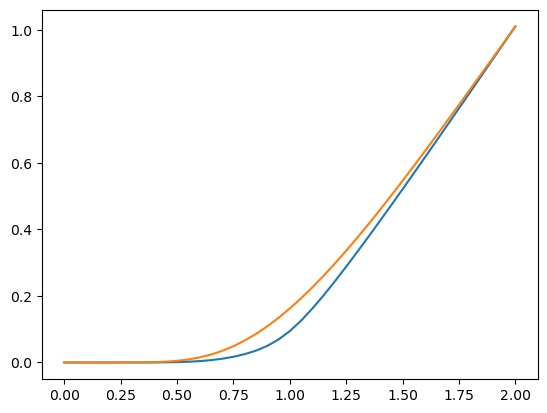

In [23]:
plt.plot(S,V_L)
plt.plot(S,V_H)